# Lab 1 Homework (your own tools, on the Reddit dataset)

This is the homework: the same eighteen tools you built in
`DM2026-Lab1-AgentDev.ipynb`, run by the same kind of
analysis agent as `DM2026-Lab1-AgenticPipeline.ipynb`, but against
a different dataset, `newdataset/Reddit-stock-sentiment.csv` instead
of 20-newsgroups. Nothing about your tools needs to change; a tool that
works on one dataset should work on any dataset shaped the way
`load_dataset_tool` normalizes it (a `text` column and a `category`/
`category_name` label), and this is where that actually gets tested.

You don't need to have finished every tool file to try this. Files that
are missing, incomplete, or still error out are skipped and reported;
whatever tools did load successfully are still discoverable. If a tool
that worked fine on 20-newsgroups breaks here, that's worth noticing,
not working around: it usually means it was quietly relying on
something about that specific dataset rather than being general.

## 0. Setup: your name, a backend, and its API key

Same name and student ID, same two backends (`groq`, `gemini`) as the
other two notebooks. Uses the same `config/.env` key you already set
up. **Groq is the recommended default**: it responds noticeably
faster for these tool-calling turns (Gemini has been observed taking up
to about a minute on a single turn, sometimes failing outright, where
Groq typically answers in a few seconds). Use Gemini as a fallback once
Groq's rate limit runs out, not as your primary choice.

If you've configured more than one key, **we strongly recommend
enabling multi-provider fallback**: if your chosen backend hits a rate
limit mid-session, the agent automatically retries with the next
configured backend instead of leaving you stuck. This isn't a rare
edge case: both providers' free tiers reset only once a day (Groq at
midnight UTC, Gemini at midnight Pacific time), so running out mid-
session means waiting hours, not minutes, unless the other backend
picks up automatically. Off by default; turn it on if you have both
keys configured, since there's little reason not to.

Type `/status` in the chat at any point to see which of your keys
are still active and which have hit a rate limit this session,
handled entirely by the chat widget itself, not the agent, so it
never uses a turn or shows up in your graded log.

Run the cell below, fill it in, and click **Confirm** before moving on
to the next cell.

In [ ]:
from agent_pipeline.backend_widget import select_backend

backend_choice = select_backend()

## 1. Discover your tools

Same two sources as the agentic-pipeline notebook: `agent_dev_workspace/`
(the eighteen tools you built yourself) and `premade_tools/`
(`load_dataset_tool` and `visualize_result_tool`, already built for
you). Nothing here is homework-specific; it's the exact same discovery
step, over the exact same tool files. The dataset only enters the
picture once you actually ask the agent to load one, in the chat
below.

In [3]:
from agent_pipeline.session_state import SessionState
from agent_pipeline.workspace_loader import load_workspace_tools
from agent_pipeline.tool_access import build_gated_tools

session = SessionState()
student_tools, student_problems = load_workspace_tools("agent_dev_workspace", session)
premade_tools, premade_problems = load_workspace_tools("premade_tools", session)
tools = build_gated_tools(student_tools, session, premade_tools=premade_tools)
problems = student_problems + premade_problems

print(f"Your tools ({len(student_tools)}, need your approval to run): {[t.name for t in student_tools]}")
print(f"Provided tools ({len(premade_tools)}, usable right away): {[t.name for t in premade_tools]}")
if problems:
    print("\nNot loaded:")
    for fname, message in problems:
        print(f"  {fname}: {message}")
if not student_tools:
    print("\nNo tools of your own discovered yet. Build something in the developer-stage notebook first.")

Your tools (17, need your approval to run): ['list_files_tool', 'inspect_data_tool', 'check_missing_tool', 'check_duplicates_tool', 'sample_data_tool', 'describe_data_tool', 'build_dtm_tool', 'term_frequency_tool', 'dtm_heatmap_tool', 'cosine_similarity_tool', 'feature_correlation_matrix_tool', 'variance_filter_tool', 'pearson_filter_tool', 'spearman_filter_tool', 'mine_patterns_tool', 'reduce_dimensions_tool', 'binarize_labels_tool']
Provided tools (2, usable right away): ['load_dataset_tool', 'visualize_result_tool']


## The dataset for this homework

`newdataset/Reddit-stock-sentiment.csv`: 847 Reddit posts/comments about
stocks, each with a sentiment label. The two columns that matter for
`load_dataset_tool` are `text` (the post/comment content) and `label`
(`-1.0` negative, `0.0` neutral, `1.0` positive: 315 / 423 / 109
rows respectively). Every other column (`upvotes`, `subreddit`,
`polarity`, and so on) is there in the raw file but not something
`load_dataset_tool` reads; your tools only ever see what it normalizes
into `session.dataframe`.

Ask the agent to load it with:
`file_path="newdataset/Reddit-stock-sentiment.csv"`,
`text_column="text"`, `label_column="label"`. From there, every other
tool works exactly the way it did in the agentic-pipeline notebook,
the same one-time batch grant for all of your own tools together, the
same one-tool-call-per-turn rule, the same everything. Only the data
underneath changed.

## What to try

The chat is below, once you run the next cell. Same mechanics as the
agentic-pipeline notebook, same tagging convention as the
developer-stage notebook: a `[PROMPT]` line is close to what you'd
actually type, an `[INSTRUCTION, not a prompt]` line tells you what to
do or ask in your own words, no fixed line to type there.

1. **[PROMPT]** `What tools do I have?` (list_available_tools_tool, no grant needed for anything)
2. **[PROMPT]** `Run load_dataset_tool with file_path="newdataset/Reddit-stock-sentiment.csv", text_column="text", label_column="label"` (one of the two provided tools: this just runs, no request needed, three-class sentiment instead of the two newsgroup categories you tried before)
3. **[INSTRUCTION, not a prompt]** Ask what one of your own tools does, before running it (describe_tool_tool, still no grant)
4. **[INSTRUCTION, not a prompt]** Ask to run one of your own tools. The agent should request access to all of your own tools at once, as a single batch, and explain why, then stop and wait
5. **[PROMPT]** `Yes, go ahead`. This grants every one of your own tools together, not just the one you asked about; from here on, any of them runs directly, no further requests
6. **[INSTRUCTION, not a prompt]** Work through your tools in the same order as `DM2026-Lab1-AgenticPipeline.ipynb`'s "The full pipeline, step by step" section: build the document-term matrix before filtering, filter before mining patterns or reducing dimensions, and so on. Same dependency chain, just pointed at a different dataset this time.

If a tool behaves differently here than it did on 20-newsgroups (three
label values instead of two, different vocabulary, shorter or messier
text), that's real signal about how general your implementation
actually is, not something to route around.

**If the agent's reply is just "(No response came back for that. Ask
it to summarize what happened, or go ahead with your next question.)"**,
this can happen right after any tool call, and it isn't the session
getting stuck or a bug in this notebook. Behind the scenes, an empty
reply is automatically retried several more times, switching to a
different key or backend each time if you have more than one
configured, before this message ever shows, so seeing it at all means
every one of those attempts came back with nothing usable. The tool
call itself already ran and its real result is still shown above that
placeholder, whatever you actually asked for; what's missing is only
the follow-up comment on it. Just do what the placeholder says: ask
the agent to summarize what happened, or go straight to your next
question. It doesn't mean anything is wrong with your tools, and
there's nothing to restart.

## 2. Build the graph and launch the chat

Same structural rules as both other notebooks: one tool call per
message, a mandatory discuss-only follow-up, and a numeric grounding
check on everything the agent says.

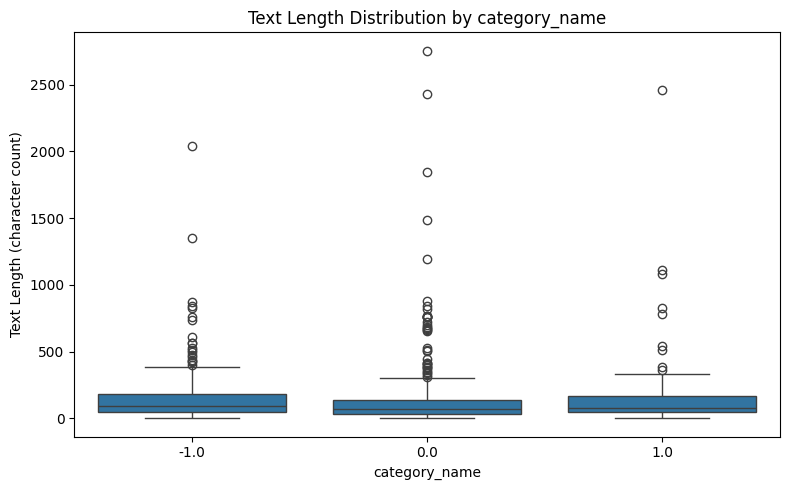

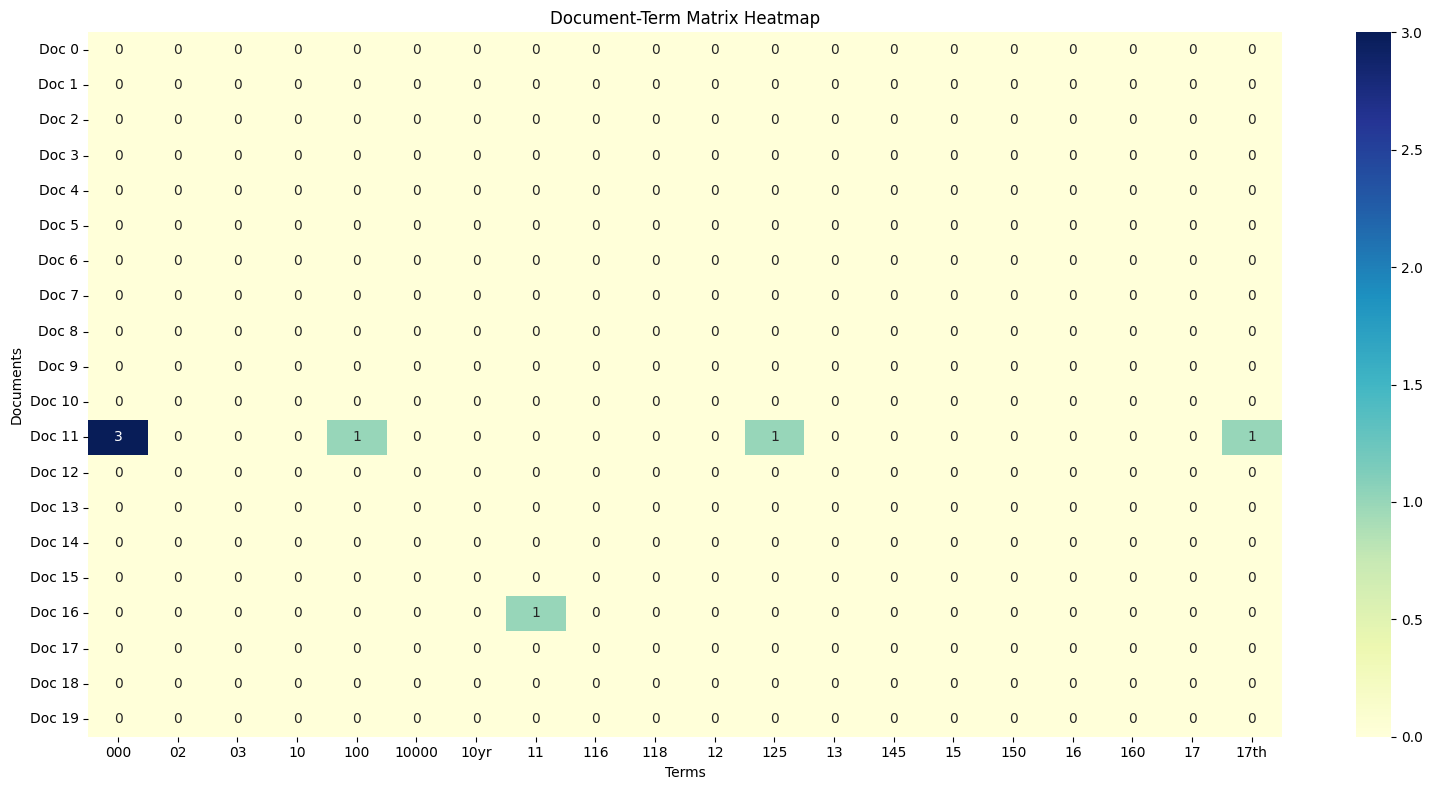

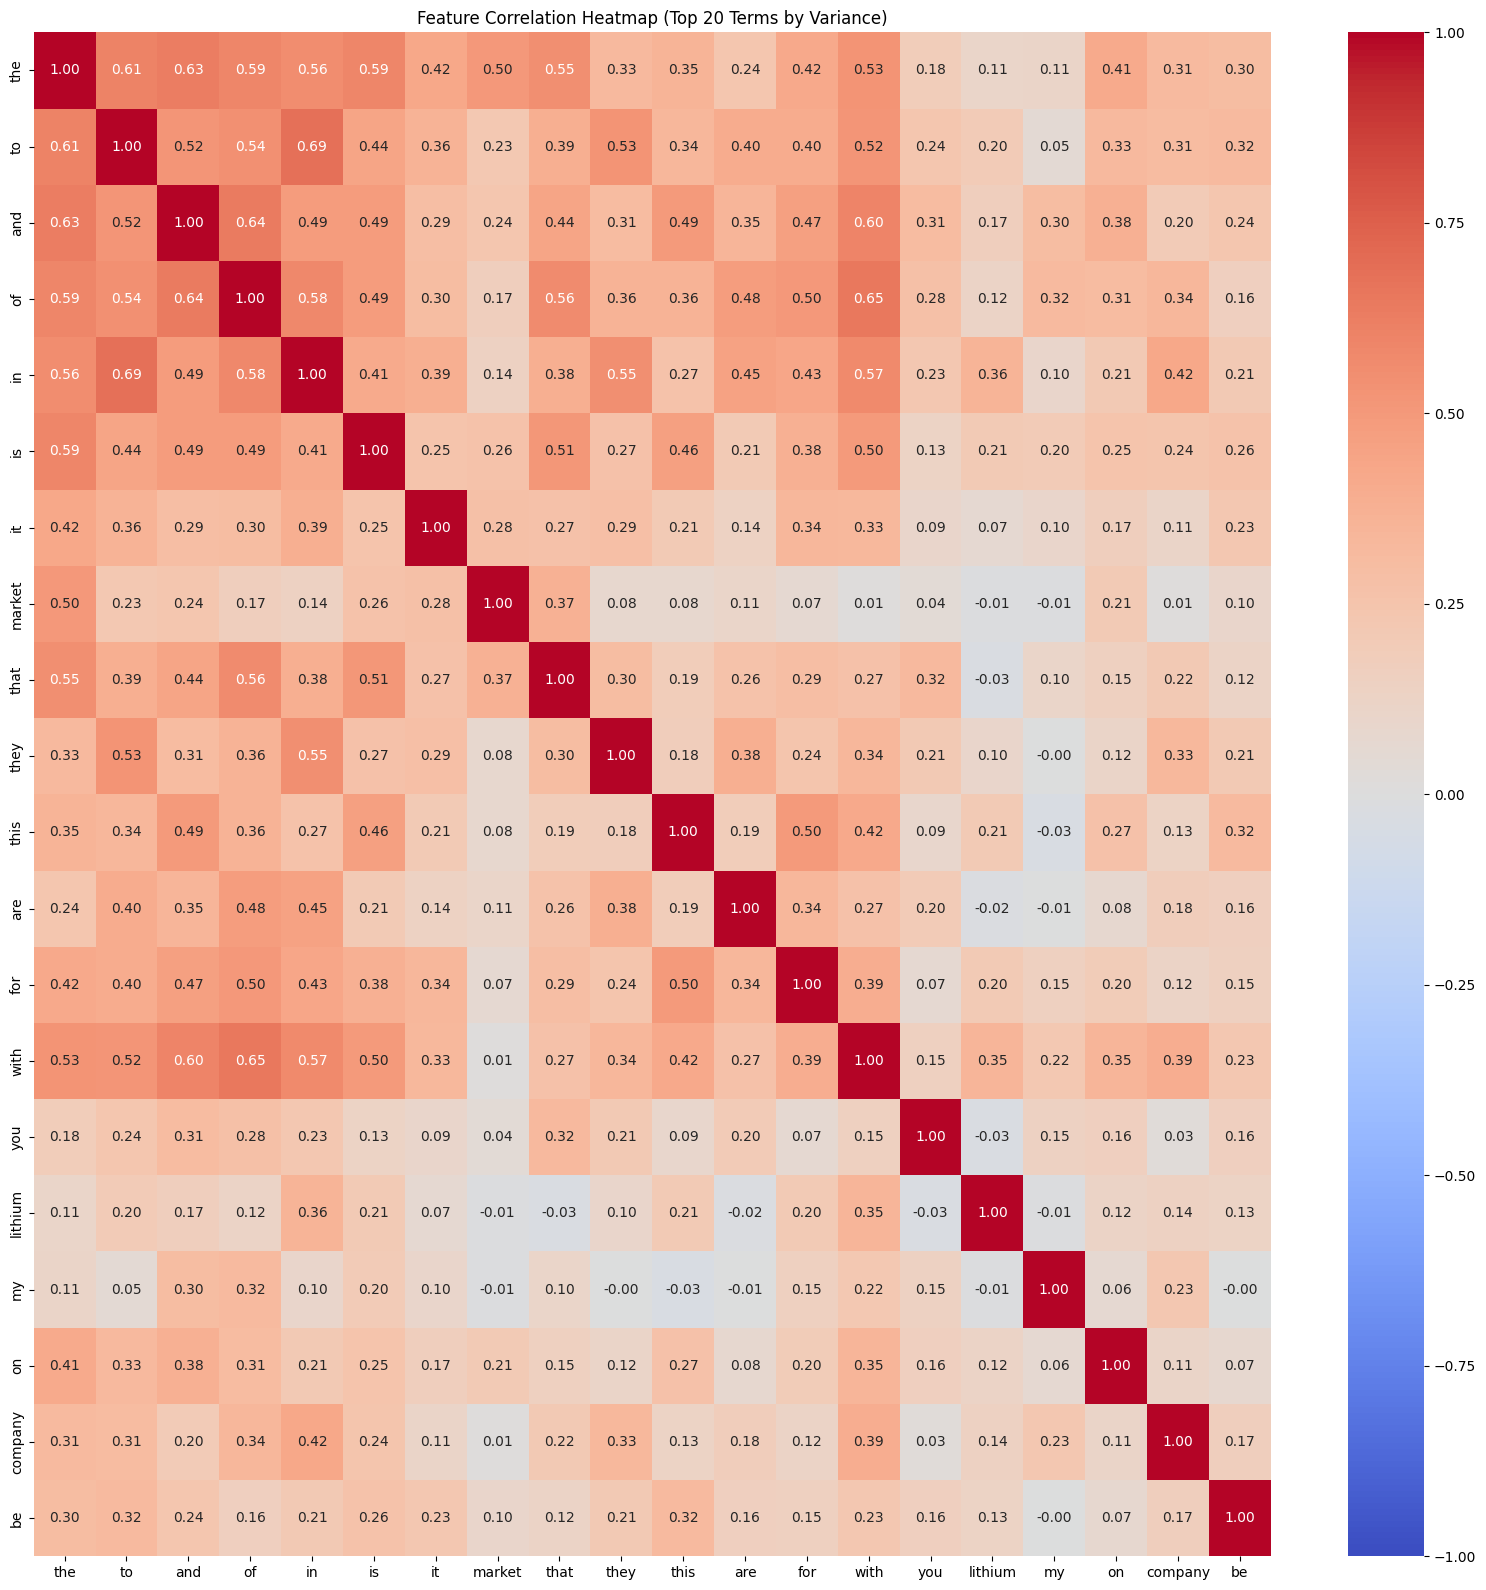

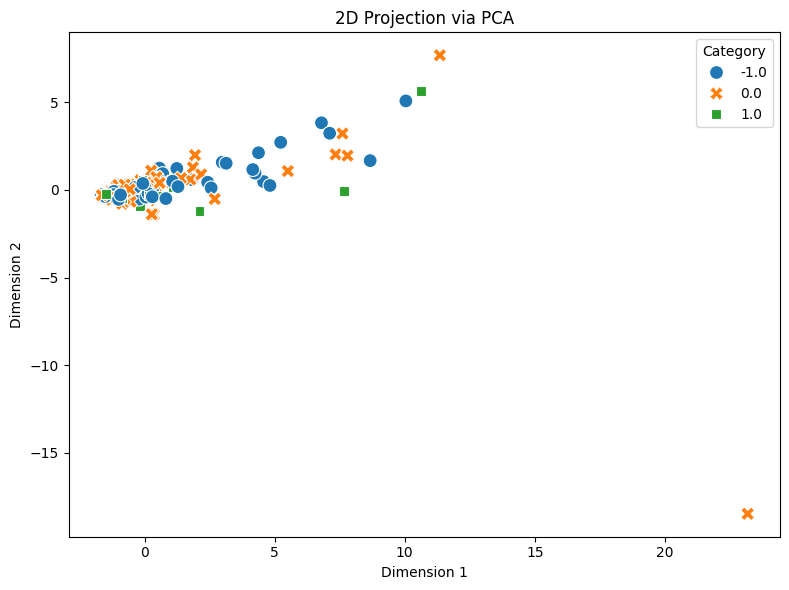

In [4]:
SYSTEM_PROMPT = """You are a data mining lab assistant running analysis \
tools for the student's Lab 1 homework. Some of these tools the student \
wrote themselves, not a finished reference implementation, and may be \
missing, incomplete, or buggy since they're still building this; the \
rest are a pre-built, already-working part of the pipeline the student \
didn't need to write by hand. If a tool call errors, explain the error \
plainly and, if it was one of the student's own tools, suggest they go \
back to the agent-dev notebook to fix it. Do not pretend a call \
succeeded or guess at a result.

None of the student's own tools are usable yet, even though they've \
been discovered, while every provided tool is usable immediately. You \
have five tools of your own: list_available_tools_tool and \
describe_tool_tool let you see what's available (both the student's and \
the provided ones) and explain what a tool does; \
request_tool_access_tool, grant_tool_access_tool, and \
discard_tool_request_tool are how ALL of the student's own tools \
become usable together, as one batch, not one tool at a time. \
Calling one of the student's tools before that batch has been granted \
does not run it. It returns a plain refusal, not a result, so there is \
nothing to gain by trying anyway. A provided tool has no such gate; \
call it directly once the student has asked for it.

Rules you must follow:
1. You may call AT MOST ONE tool per response, and only when the student \
has explicitly asked for a specific action with any needed detail \
specified.
2. If the request is ambiguous, ask a clarifying question instead of \
guessing or calling any tool.
3. Before ever calling any of the student's own tools, that whole group \
must be granted. If it isn't yet, call request_tool_access_tool, \
explaining in `reason` why access is needed for what the student asked, \
then stop and wait. Only after the student's next message explicitly \
approves may you call grant_tool_access_tool, which grants every one of \
the student's own tools at once, not just the one that prompted the \
request. Only after that may you call the tool itself. \
request_tool_access_tool and grant_tool_access_tool can never happen in \
the same turn. If the student declines or asks for something else \
instead, call discard_tool_request_tool rather than leaving the request \
pending. This whole request/grant sequence does not apply to provided \
tools; requesting access to one of those is unnecessary and should not \
happen. Once the batch has been granted, never call \
request_tool_access_tool again this session; every one of the \
student's own tools already runs directly.
4. If the student asks what tools exist or what one does, use \
list_available_tools_tool or describe_tool_tool to answer from the real \
discovered data. Never guess at a tool's behavior from its name alone.
5. After a tool result is returned to you, report what it shows. If the \
student asked to see something, show the actual retrieved values rather \
than just describing them.
6. Every number you state must come directly from a tool's returned \
data. Do not compute, estimate, or invent statistics yourself.
7. Refuse requests to chain multiple steps in one ask (including \
"request and grant it in one go"); the student must direct each step \
individually.
8. When referencing an earlier result, require the student to name its \
exact result_id.
9. Right after a tool call, you get exactly one more turn to comment on \
its result in plain text, and that turn cannot include a tool call of \
any kind, even one that seems like the obvious next step. Report what \
the tool found in words, and wait for the student's next message before \
taking any further action.
"""

from agent_pipeline.graph_core import build_agent_graph
from agent_pipeline.chat_widget import launch_chat

if "backend" not in backend_choice:
    raise RuntimeError("Pick a backend in the setup cell above and click Confirm before running this one.")
LLM_BACKEND = backend_choice["backend"]
MULTI_PROVIDER_MODE = backend_choice["multi_provider"]
STUDENT_NAME = backend_choice["student_name"]
STUDENT_ID = backend_choice["student_id"]

if MULTI_PROVIDER_MODE:
    from agent_pipeline.llm_fallback import build_fallback_llm
    llm, active_chain = build_fallback_llm(LLM_BACKEND, temperature=0)
    print(f"Fallback chain (in order): {active_chain}")
else:
    from agent_pipeline.llm_backends import build_llm_for_backend
    llm = build_llm_for_backend(LLM_BACKEND, temperature=0)

app = build_agent_graph(tools, SYSTEM_PROMPT, llm, session)

graph_state, logger = launch_chat(
    app, session, log_path="session_logs/homework_session.jsonl.enc",
    student_name=STUDENT_NAME, student_id=STUDENT_ID, track="homework",
    plots_dir="plots",
    placeholder="Ask the agent to load the Reddit dataset or run one of your tools... (or type /status to see key rotation status)",
    llm=llm,
)

## 3. Write your report

Every plot a tool produces (`reduce_dimensions_tool`, `visualize_result_tool`)
is saved automatically as you go, to `plots/`, named
`YourName_homework_plot_<result_id>.png` (your own name, as you typed
it in the setup cell, standing in for `YourName` here). Nothing extra
to do to save one; it happens the moment the tool runs.

**Your report is not written in this notebook.** Run the cell below
once to create your own report file:

```
reports/YourName_YourStudentID_homework_report.md
```

Open that file directly (in JupyterLab's file browser, VS Code, or any
text editor) and write your report there: a short report, as if
explaining your findings to someone who never saw the conversation,
what you ran on the Reddit dataset, what it found, and what that
means, referencing specific `result_id`s and specific saved plots.
Embed a plot with a normal markdown image link, using your own actual
filename from `plots/` (check the printed "plot saved to..." message
or the file listing at the bottom of this notebook for the exact name).
**Use `../plots/...`, not `plots/...`**: your report file lives inside
`reports/`, one folder below the repo root, while `plots/` is a
sibling of `reports/` at the root, so the link needs to step back out
first:
```
![Variance filter result](../plots/YourName_homework_plot_variance_1.png)
```

**This is graded separately from the conversation above.** The chat is
judged on how well you directed the agent; this report is judged
on whether the analysis itself is correct and clearly communicated. A
well-directed conversation doesn't substitute for a real report, and a
good report doesn't excuse a conversation that was all vague requests
rubber-stamped without engagement; they're scored independently.

## Create your report file

Run this once. It creates an empty report file for you to write in,
named with your name, your student ID, and this notebook's track, the
exact same name and ID you entered in the setup cell above. Safe to
re-run later: it never overwrites a file that already exists, so
running it again after you've started writing won't erase your work.

In [6]:
from pathlib import Path

def _safe_stem(name: str) -> str:
    stem = "".join(c if c.isalnum() else "_" for c in name).strip("_")
    return stem or "unknown"

_TRACK = "homework"
_PLACEHOLDER = (
    "*(Replace this with your own report: 3-5 short paragraphs. For each "
    "major step you actually ran, loading the data, filtering, pattern "
    "mining, dimension reduction, whatever applies, say what you did, "
    "reference the specific `result_id` and/or saved plot, and explain "
    "what it shows. Delete this instruction text before submitting.)*"
)

reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)
report_path = reports_dir / f"{_safe_stem(STUDENT_NAME)}_{STUDENT_ID}_{_TRACK}_report.md"

if report_path.exists():
    print(f"Already exists, left untouched: {report_path}")
else:
    report_path.write_text(f"# Your report\n\n{_PLACEHOLDER}\n", encoding="utf-8")
    print(f"Created: {report_path}")

print("Open that file and write your report there, not in this notebook.")

Created: reports\Nuran_Daniel_Koller_J154020003_homework_report.md
Open that file and write your report there, not in this notebook.


## 4. Submitting your work

Three things to submit, all from this notebook:

1. **The session log**, `session_logs/homework_session.jsonl.enc`, logged
   turn by turn as you go, encrypted with the same grading key used by
   the other notebooks. You can't read your own log back.
2. **The plots folder**, `plots/`: every plot your
   tools produced, saved automatically, referenced from your report.
3. **Your report**,
   `reports/YourName_YourStudentID_homework_report.md`, from "Create
   your report file" above. Same name and ID as your log.

Upload all three, alongside the developer-stage and agentic-pipeline logs,
not instead of them.

**Important: these folders are gitignored by default.** `session_logs/`,
`plots/`, and `reports/` are left out of this shared repo on purpose, so a
plain `git add .` silently skips them and your pushed fork ends up
without your log, plots, or report. Before your final commit, force-add
them explicitly:

```
git add -f session_logs plots reports
git commit -m "homework submission"
git push
```

Run `git status` afterward and confirm they show up as committed.

In [7]:
import os

log_path = "session_logs/homework_session.jsonl.enc"
if os.path.exists(log_path):
    print(f"Log file present: {log_path} ({os.path.getsize(log_path)} bytes)")
else:
    print("No log yet. Send at least one message in the chat above first.")

plots_dir = "plots"
if os.path.isdir(plots_dir):
    plot_files = sorted(os.listdir(plots_dir))
    print(f"Plots saved ({len(plot_files)}): {plot_files}")
else:
    print("No plots saved yet -- expected if you haven't run a plotting tool.")

if "report_path" not in globals():
    print("No report file yet. Run \"Create your report file\" above first, then re-run this cell.")
elif os.path.exists(report_path):
    text = open(report_path, encoding="utf-8").read()
    if "Replace this with your own report" in text:
        print(f"Report file present but still the placeholder: {report_path}")
    else:
        print(f"Report file present and written: {report_path} ({os.path.getsize(report_path)} bytes)")
else:
    print("No report file yet. Run \"Create your report file\" above first.")

Log file present: session_logs/homework_session.jsonl.enc (292765 bytes)
Plots saved (12): ['Nuran_Daniel_Koller_agentic-pipeline_plot_describe_data_5.png', 'Nuran_Daniel_Koller_agentic-pipeline_plot_dtm_heatmap_10.png', 'Nuran_Daniel_Koller_agentic-pipeline_plot_dtm_heatmap_12.png', 'Nuran_Daniel_Koller_agentic-pipeline_plot_dtm_heatmap_9.png', 'Nuran_Daniel_Koller_agentic-pipeline_plot_feature_correlation_matrix_14.png', 'Nuran_Daniel_Koller_agentic-pipeline_plot_reduce_dimensions_16.png', 'Nuran_Daniel_Koller_agentic-pipeline_plot_turn100.png', 'Nuran_Daniel_Koller_homework_plot_describe_data_5.png', 'Nuran_Daniel_Koller_homework_plot_dtm_heatmap_10.png', 'Nuran_Daniel_Koller_homework_plot_feature_correlation_matrix_13.png', 'Nuran_Daniel_Koller_homework_plot_reduce_dimensions_15.png', 'Nuran_Daniel_Koller_homework_plot_turn72.png']
Report file present and written: reports\Nuran_Daniel_Koller_J154020003_homework_report.md (2428 bytes)
